<a href="https://colab.research.google.com/github/anamelbsi/projeto-ic-segmentacao/blob/main/segmentacao_corpos_dagua/YOLO26/yolo%2026%20corpos%20d'%C3%A1gua.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile
import shutil
from pathlib import Path

zip_path = Path('/content/drive/MyDrive/waterbodiesdataset.zip')
base_path = Path('/content/water_bodies')

if base_path.exists():
    shutil.rmtree(base_path)
base_path.mkdir()

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(base_path)

Mounted at /content/drive


In [ ]:
from pathlib import Path
base_path = Path('/content/water_bodies/Water Bodies Dataset')

In [ ]:
from pathlib import Path
base_path = Path('/content/water_bodies/Water Bodies Dataset')
images_path = base_path / 'Images'
masks_path = base_path / 'Masks'
imagens = list(images_path.glob('*.jpg'))
masks = list(masks_path.glob('*.jpg'))

In [ ]:
import shutil
from pathlib import Path
import random

orig_path = Path('/content/water_bodies/Water Bodies Dataset')
yolo_path = Path('/content/yolo_dataset')

if yolo_path.exists():
    shutil.rmtree(yolo_path)

(yolo_path / 'images/train').mkdir(parents=True)
(yolo_path / 'images/val').mkdir(parents=True)
(yolo_path / 'masks/train').mkdir(parents=True)
(yolo_path / 'masks/val').mkdir(parents=True)

imagens = list((orig_path / 'Images').glob('*.jpg'))
random.shuffle(imagens)

split_idx = int(len(imagens) * 0.8)
train_imgs = imagens[:split_idx]
val_imgs = imagens[split_idx:]

for img in train_imgs:
    nome = img.name
    shutil.copy(img, yolo_path / f'images/train/{nome}')
    shutil.copy(orig_path / 'Masks' / nome, yolo_path / f'masks/train/{nome}')

for img in val_imgs:
    nome = img.name
    shutil.copy(img, yolo_path / f'images/val/{nome}')
    shutil.copy(orig_path / 'Masks' / nome, yolo_path / f'masks/val/{nome}')

In [ ]:
import cv2
import numpy as np
from pathlib import Path
from skimage import measure

def mask_to_yolo_polygon(mask_path, output_txt_path, class_id=0, min_area=50):
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return False
    _, mask_bin = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    h, w = mask_bin.shape
    contours, _ = cv2.findContours(mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return False
    with open(output_txt_path, 'w') as f:
        for contour in contours:
            epsilon = 0.001 * cv2.arcLength(contour, True)
            approx = cv2.approxPolyDP(contour, epsilon, True)
            points = approx.reshape(-1, 2).astype(np.float32)
            points[:, 0] /= w
            points[:, 1] /= h
            area = cv2.contourArea(contour)
            if area < min_area:
                continue
            line = f"{class_id} " + " ".join([f"{coord:.6f}" for coord in points.flatten()])
            f.write(line + "\n")
    return True

yolo_path = Path('/content/yolo_dataset')
(yolo_path / 'labels/train').mkdir(parents=True, exist_ok=True)
(yolo_path / 'labels/val').mkdir(parents=True, exist_ok=True)

train_masks = list((yolo_path / 'masks/train').glob('*.jpg'))
for mask_path in train_masks:
    txt_path = yolo_path / 'labels/train' / mask_path.with_suffix('.txt').name
    mask_to_yolo_polygon(mask_path, txt_path)

val_masks = list((yolo_path / 'masks/val').glob('*.jpg'))
for mask_path in val_masks:
    txt_path = yolo_path / 'labels/val' / mask_path.with_suffix('.txt').name
    mask_to_yolo_polygon(mask_path, txt_path)

In [ ]:
!pip install ultralytics -q

from ultralytics import YOLO
import torch

model = YOLO('yolo26n-seg.pt')

yaml_content = f"""
path: /content/yolo_dataset
train: images/train
val: images/val
names:
  0: water
"""

with open('/content/dataset.yaml', 'w') as f:
    f.write(yaml_content)

model.train(
    data='/content/dataset.yaml',
    epochs=10,
    imgsz=320,
    batch=4,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    patience=3,
    save=True,
    project='water_segmentation_yolo26',
    name='yolo26_run',
    workers=2,
    cache='disk'
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 53.1 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x77fbbb2caf90>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041, 


image 1/1 /content/yolo_dataset/images/val/water_body_8011.jpg: 320x320 1 water, 106.3ms
Speed: 1.5ms preprocess, 106.3ms inference, 1.4ms postprocess per image at shape (1, 3, 320, 320)

image 1/1 /content/yolo_dataset/images/val/water_body_2351.jpg: 320x256 (no detections), 102.8ms
Speed: 1.4ms preprocess, 102.8ms inference, 0.2ms postprocess per image at shape (1, 3, 320, 256)

image 1/1 /content/yolo_dataset/images/val/water_body_996.jpg: 320x224 1 water, 80.7ms
Speed: 1.7ms preprocess, 80.7ms inference, 1.2ms postprocess per image at shape (1, 3, 320, 224)


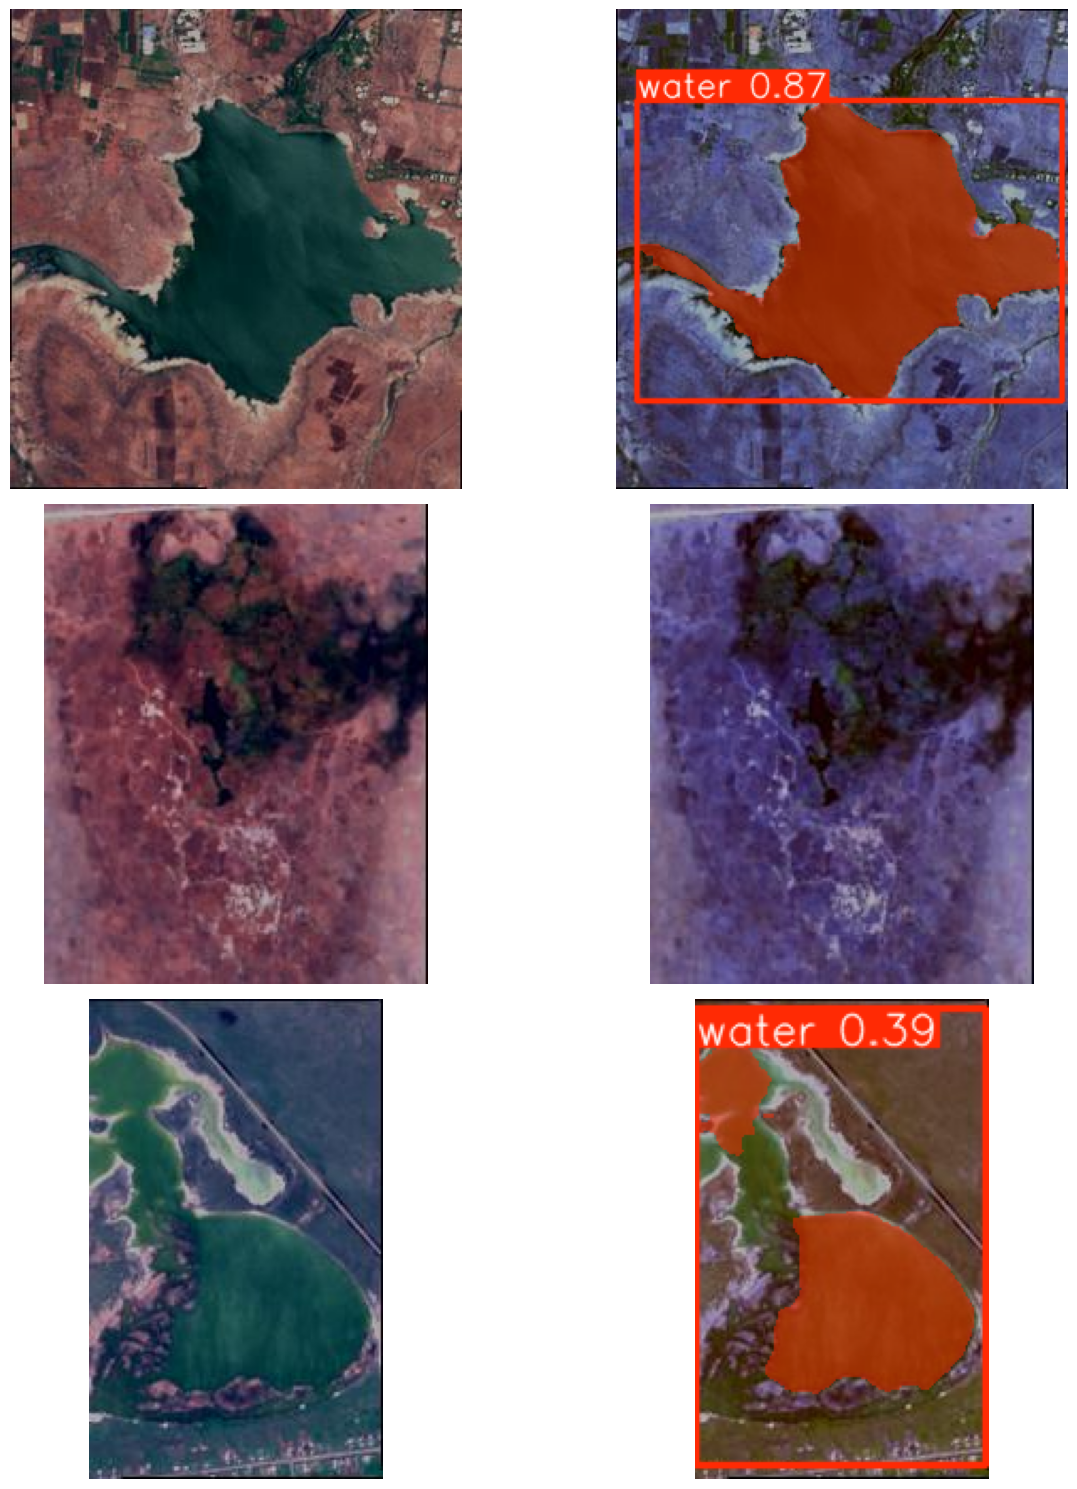

In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import random

model = YOLO('/content/runs/segment/water_segmentation_yolo26/yolo26_run/weights/best.pt')

val_images = list(Path('/content/yolo_dataset/images/val').glob('*.jpg'))
if not val_images:
    val_images = list(Path('/content/yolo_dataset/images/train').glob('*.jpg'))

sample_images = random.sample(val_images, min(3, len(val_images)))

fig, axes = plt.subplots(len(sample_images), 2, figsize=(14, 5*len(sample_images)))

for i, img_path in enumerate(sample_images):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    results = model(img_path, conf=0.25)[0]

    if len(sample_images) > 1:
        ax_orig = axes[i, 0]
        ax_pred = axes[i, 1]
    else:
        ax_orig = axes[0]
        ax_pred = axes[1]

    ax_orig.imshow(img)
    ax_orig.axis('off')

    img_with_masks = results.plot()
    ax_pred.imshow(img_with_masks)
    ax_pred.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from ultralytics import YOLO
import cv2
import numpy as np
from pathlib import Path

def calculate_iou(mask_pred, mask_true):
    mask_pred_bin = (mask_pred > 0.5).astype(np.uint8)
    mask_true_bin = (mask_true > 0).astype(np.uint8)
    intersection = np.logical_and(mask_pred_bin, mask_true_bin).sum()
    union = np.logical_or(mask_pred_bin, mask_true_bin).sum()
    if union == 0:
        return 1.0 if intersection == 0 else 0.0
    return intersection / union

model = YOLO('/content/runs/segment/water_segmentation_yolo26/yolo26_run/weights/best.pt')

val_images = Path('/content/yolo_dataset/images/val')
val_masks = Path('/content/yolo_dataset/masks/val')

ious = []

for img_path in sorted(val_images.glob('*.jpg'))[:20]:
    nome = img_path.stem
    mask_true_path = val_masks / f"{nome}.jpg"
    if not mask_true_path.exists():
        continue

    mask_true = cv2.imread(str(mask_true_path), cv2.IMREAD_GRAYSCALE)
    _, mask_true = cv2.threshold(mask_true, 127, 1, cv2.THRESH_BINARY)

    results = model(img_path, conf=0.25, verbose=False)[0]

    if results.masks is None:
        continue

    h, w = mask_true.shape
    mask_pred = np.zeros((h, w), dtype=np.uint8)

    for mask in results.masks.data:
        mask_resized = cv2.resize(mask.cpu().numpy(), (w, h))
        mask_pred = np.logical_or(mask_pred, mask_resized > 0.5).astype(np.uint8)

    iou = calculate_iou(mask_pred, mask_true)
    ious.append(iou)

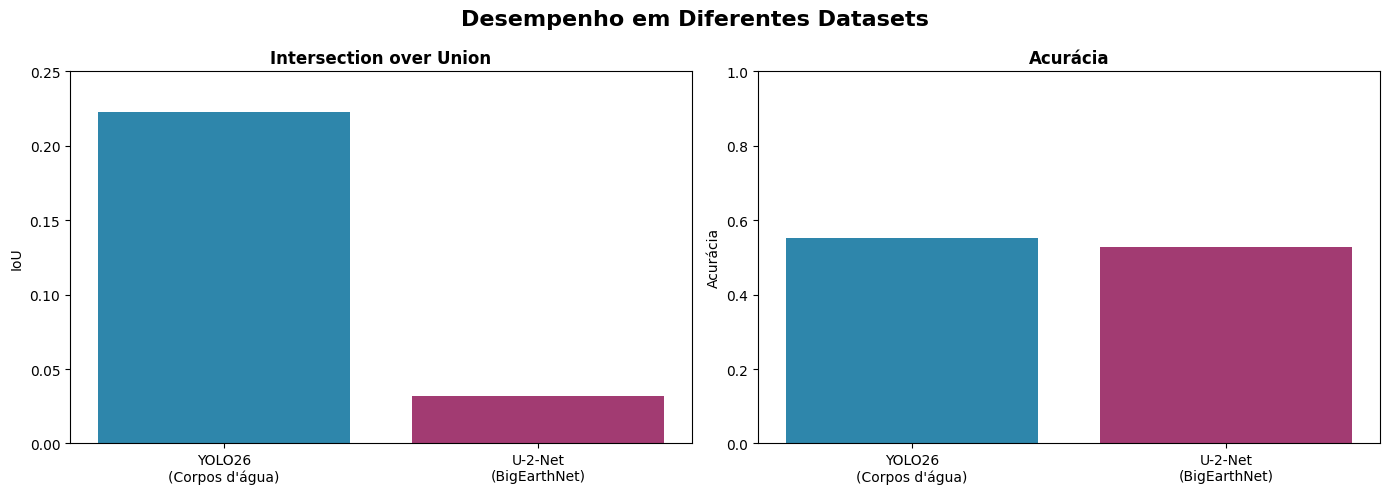

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

yolo_iou = 0.223
yolo_accuracy = 0.553
u2net_iou = 0.032
u2net_accuracy = 0.529

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Desempenho em Diferentes Datasets', fontsize=16, fontweight='bold')

ax1 = axes[0]
bars1 = ax1.bar(['YOLO26\n(Corpos d\'água)', 'U-2-Net\n(BigEarthNet)'],
                [yolo_iou, u2net_iou], color=['#2E86AB', '#A23B72'])
ax1.set_ylabel('IoU')
ax1.set_title('Intersection over Union', fontweight='bold')
ax1.set_ylim(0, 0.25)

ax2 = axes[1]
bars2 = ax2.bar(['YOLO26\n(Corpos d\'água)', 'U-2-Net\n(BigEarthNet)'],
                [yolo_accuracy, u2net_accuracy], color=['#2E86AB', '#A23B72'])
ax2.set_ylabel('Acurácia')
ax2.set_title('Acurácia', fontweight='bold')
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()